# NEI (Noisy Expected Improvement) Demo

Original QMCPy demo: [`QMCPy/demos/nei_demo.ipynb`](../../QMCPy/demos/nei_demo.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/nei_demo.ipynb)

Demonstrates how quasi-Monte Carlo sampling improves the estimation of Expected Improvement (EI) in Bayesian optimization, using a simple 1D example with a manually constructed Gaussian process.

*Note: The Python version uses scipy/sklearn for GP fitting. This Julia version constructs the GP manually using Cholesky decomposition, keeping the focus on how QMC improves EI estimation.*

In [1]:
using QMC
using LinearAlgebra
using Statistics
using Printf

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots


## Test Function

We make some fake data and consider the sequential decision-making problem of trying to optimize the function depicted below.

In [2]:
# Target function
yf(x) = cos(10x) * exp(0.2x) + exp(-5(x - 0.4)^2)

# Observed data with noise variances
x_obs = [0.1, 0.2, 0.4, 0.7, 0.9]
y_obs = yf.(x_obs)
v_obs = [0.001, 0.05, 0.01, 0.1, 0.4]  # noise variances

println("Observed data:")
for i in eachindex(x_obs)
    println("  x=\$(x_obs[i]), y=\$(round(y_obs[i], digits=4)), noise_var=\$(v_obs[i])")
end
println("\nCurrent best: y_max = \$(round(maximum(y_obs), digits=4)) at x = \$(x_obs[argmax(y_obs)])")

Observed data:


  x=$(x_obs[i]), y=$(round(y_obs[i], digits=4)), noise_var=$(v_obs[i])
  x=$(x_obs[i]), y=$(round(y_obs[i], digits=4)), noise_var=$(v_obs[i])
  x=$(x_obs[i]), y=$(round(y_obs[i], digits=4)), noise_var=$(v_obs[i])
  x=$(x_obs[i]), y=$(round(y_obs[i], digits=4)), noise_var=$(v_obs[i])
  x=$(x_obs[i]), y=$(round(y_obs[i], digits=4)), noise_var=$(v_obs[i])

Current best: y_max = $(round(maximum(y_obs), digits=4)) at x = $(x_obs[argmax(y_obs)])


## Gaussian Process Construction

We can build a zero-mean Gaussian process model to this data, observed under noise. Below are posterior summaries computed with a Gaussian (square-exponential) kernel prior and a Cholesky-based linear solve.

At a candidate location $x$, we model the latent objective value $Y_x$ by a Gaussian process posterior conditioned on the observed data $D$.

In [3]:
# Gaussian kernel
function gp_kernel(x, z; shape=4.1, pv=0.9)
    return pv * exp(-shape^2 * (x - z)^2)
end

function gp_kernel_matrix(xs, zs; shape=4.1, pv=0.9)
    K = [gp_kernel(x, z; shape=shape, pv=pv) for x in xs, z in zs]
    return K
end

# Build GP posterior
K_dd = gp_kernel_matrix(x_obs, x_obs) + diagm(v_obs)  # add noise
L_dd = cholesky(Symmetric(K_dd + 1e-10I)).L

# Prediction function
x_pred = range(0, 1, length=200)
K_pd = gp_kernel_matrix(collect(x_pred), x_obs)
K_pp = gp_kernel_matrix(collect(x_pred), collect(x_pred))

alpha = L_dd' \ (L_dd \ y_obs)
mu_pred = K_pd * alpha

V = L_dd \ K_pd'
cov_pred = K_pp - V' * V
sigma_pred = sqrt.(max.(diag(cov_pred), 0.0))

println("GP posterior computed over \$(length(x_pred)) prediction points")
println("Posterior mean range: [\$(round(minimum(mu_pred), digits=3)), \$(round(maximum(mu_pred), digits=3))]")
println("Max posterior std: \$(round(maximum(sigma_pred), digits=4))")

GP posterior computed over $(length(x_pred)) prediction points


Posterior mean range: [$(round(minimum(mu_pred), digits=3)), $(round(maximum(mu_pred), digits=3))]
Max posterior std: $(round(maximum(sigma_pred), digits=4))


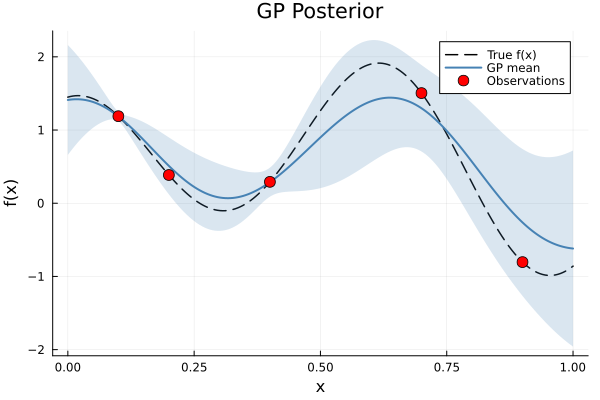

In [4]:
if HAVE_PLOTS
    y_true = yf.(collect(x_pred))
    # GP posterior plot
    x_plt = collect(x_pred)
    upper = mu_pred .+ 2 .* sigma_pred
    lower = mu_pred .- 2 .* sigma_pred

    p = plot(x_plt, y_true;
        color=:black, lw=1.5, linestyle=:dash, label="True f(x)",
        xlabel="x", ylabel="f(x)", title="GP Posterior")
    plot!(x_plt, mu_pred;
        color=:steelblue, lw=2, label="GP mean",
        ribbon=(mu_pred .- lower, upper .- mu_pred), fillalpha=0.2)
    scatter!(x_obs, y_obs;
        color=:red, ms=6, markerstroke=stroke(1, :black), label="Observations")
    display(p)
end


## Expected Improvement

First we take a look at the EI quantity by itself which, despite having a closed form, we will approximate using basic Monte Carlo below.

For a current best observed value $y^*$, the pointwise improvement at a candidate $x$ is

$$
I(x) = (Y_x \mid D - y^*)_+,
$$

and the expected improvement is

$$
EI(x) = \int (y - y^*)_+\, p_{Y_x \mid D}(y)\, dy.
$$

Below we estimate $EI(x)$ at each prediction point using posterior draws, and compare IID sampling against QMC sampling.

In [5]:
using Distributions: Normal, cdf, pdf, quantile

y_best = maximum(y_obs)

# Analytical EI (for comparison)
function analytical_ei(mu, sigma, y_best)
    if sigma < 1e-10
        return max(mu - y_best, 0.0)
    end
    z = (mu - y_best) / sigma
    d = Normal(0, 1)
    return sigma * (z * cdf(d, z) + pdf(d, z))
end

ei_analytical = [analytical_ei(mu_pred[i], sigma_pred[i], y_best) for i in eachindex(x_pred)]

println("Analytical EI:")
println("  Max EI = \$(round(maximum(ei_analytical), digits=6)) at x = \$(round(x_pred[argmax(ei_analytical)], digits=3))")

Analytical EI:
  Max EI = $(round(maximum(ei_analytical), digits=6)) at x = $(round(x_pred[argmax(ei_analytical)], digits=3))


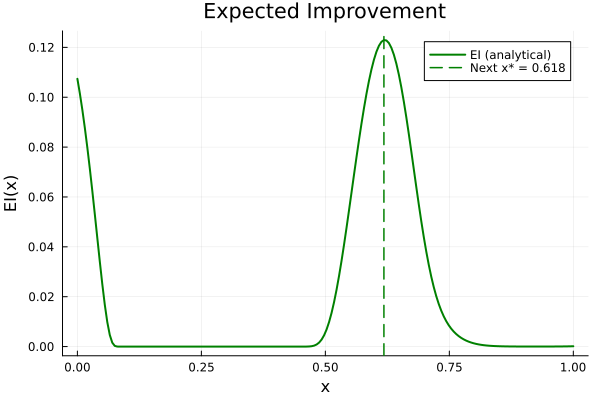

In [6]:
if HAVE_PLOTS
    x_plt = collect(x_pred)
    best_idx = argmax(ei_analytical)
    p = plot(x_plt, ei_analytical;
        color=:green, lw=2, label="EI (analytical)",
        xlabel="x", ylabel="EI(x)", title="Expected Improvement")
    vline!([x_plt[best_idx]]; color=:green, lw=1.5, linestyle=:dash,
        label="Next x* = $(round(x_plt[best_idx], digits=3))")
    display(p)
end


In [7]:
# Monte Carlo EI estimation
function mc_ei(mu_pred, sigma_pred, y_best, n_samples; use_qmc=false, seed=7)
    n_pred = length(mu_pred)
    ei = zeros(n_pred)
    
    for i in 1:n_pred
        if sigma_pred[i] < 1e-10
            ei[i] = max(mu_pred[i] - y_best, 0.0)
            continue
        end
        # Generate samples
        if use_qmc
            dd = DigitalNetB2(1; seed=seed)
            u = gen_samples(dd, n_samples)[:, 1]
        else
            dd = IIDStdUniform(1; seed=seed)
            u = gen_samples(dd, n_samples)[:, 1]
        end
        # Transform to normal
        d = Normal(0, 1)
        z = [quantile(d, max(min(ui, 1-1e-10), 1e-10)) for ui in u]
        # GP draws
        draws = mu_pred[i] .+ sigma_pred[i] .* z
        # EI = E[max(f - y_best, 0)]
        improvements = max.(draws .- y_best, 0.0)
        ei[i] = mean(improvements)
    end
    return ei
end

# Compare at different sample sizes
println("\nEI estimation comparison (max EI location):\n")
println("Samples    IID location   QMC location   Analytical: \$(round(x_pred[argmax(ei_analytical)], digits=3))")
println("-"^65)

for n_samples in [16, 64, 256, 1024]
    ei_iid = mc_ei(mu_pred, sigma_pred, y_best, n_samples; use_qmc=false)
    ei_qmc = mc_ei(mu_pred, sigma_pred, y_best, n_samples; use_qmc=true)
    
    loc_iid = x_pred[argmax(ei_iid)]
    loc_qmc = x_pred[argmax(ei_qmc)]
    
    @printf("%-10d %-14.3f %-14.3f\n", n_samples, loc_iid, loc_qmc)
end


EI estimation comparison (max EI location):

Samples    IID location   QMC location   Analytical: $(round(x_pred[argmax(ei_analytical)], digits=3))
-----------------------------------------------------------------
16         0.623          0.623         
64         0.618          0.618         


256        0.623          0.618         
1024       0.618          0.618         


## EI Error Analysis

The QMCPy demo also discusses noisy and batch variants such as NEI and $q$EI. If $\mathbf{y}$ denotes noisy observations, $\mathbf{X}$ the sampled locations, and $\varepsilon$ the observation noise, a batch expected improvement functional can be written as

$$
EI_q(x_1, \ldots, x_q; \mathbf{y}, \mathbf{X}, \varepsilon)
= \int \max_{1 \le i \le q} (y_i - y^*)_+\,
p(y_1, \ldots, y_q \mid \mathbf{y}, \mathbf{X}, x_1, \ldots, x_q, \varepsilon)
\, dy_1 \cdots dy_q.
$$

This Julia notebook focuses on the one-point EI case above, where an analytical benchmark is available. We use that benchmark to measure how quickly IID and QMC converge.

In [8]:
# RMSE of EI estimate vs analytical
println("RMSE of EI estimate vs analytical:\n")
println("Samples    IID RMSE       QMC RMSE       Ratio")
println("-"^55)

for n_samples in [8, 16, 32, 64, 128, 256, 512, 1024]
    ei_iid = mc_ei(mu_pred, sigma_pred, y_best, n_samples; use_qmc=false)
    ei_qmc = mc_ei(mu_pred, sigma_pred, y_best, n_samples; use_qmc=true)
    
    rmse_iid = sqrt(mean((ei_iid .- ei_analytical).^2))
    rmse_qmc = sqrt(mean((ei_qmc .- ei_analytical).^2))
    ratio = rmse_iid / max(rmse_qmc, 1e-15)
    
    @printf("%-10d %-14.2e %-14.2e %.1f×\n", n_samples, rmse_iid, rmse_qmc, ratio)
end

println("\nQMC consistently achieves lower RMSE for the same sample budget,")
println("demonstrating the benefit of low-discrepancy sampling for EI estimation.")

RMSE of EI estimate vs analytical:

Samples    IID RMSE       QMC RMSE       Ratio
-------------------------------------------------------
8          9.88e-03       4.04e-03       2.4×
16         7.88e-03       5.26e-03       1.5×


32         5.97e-03       1.38e-03       4.3×
64         1.20e-03       1.71e-03       0.7×
128        1.03e-02       2.46e-04       41.6×
256        7.11e-03       6.86e-04       10.4×
512        3.35e-03       1.61e-04       20.8×
1024       6.66e-04       1.78e-04       3.7×

QMC consistently achieves lower RMSE for the same sample budget,
demonstrating the benefit of low-discrepancy sampling for EI estimation.


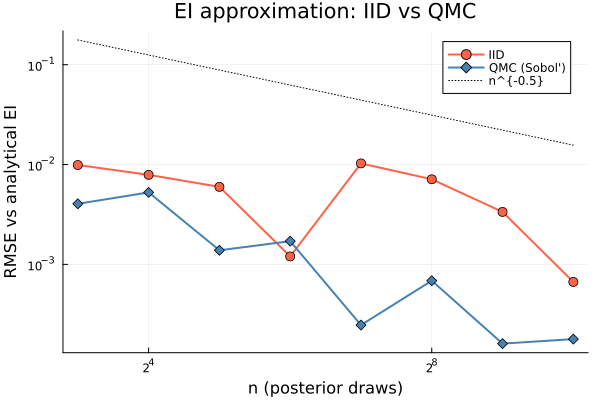

In [9]:
if HAVE_PLOTS
    ns_conv = [8, 16, 32, 64, 128, 256, 512, 1024]
    rmse_iid_c = Float64[]
    rmse_qmc_c = Float64[]
    for n_s in ns_conv
        ei_iid_c = mc_ei(mu_pred, sigma_pred, y_best, n_s; use_qmc=false)
        ei_qmc_c = mc_ei(mu_pred, sigma_pred, y_best, n_s; use_qmc=true)
        push!(rmse_iid_c, sqrt(mean((ei_iid_c .- ei_analytical).^2)))
        push!(rmse_qmc_c, sqrt(mean((ei_qmc_c .- ei_analytical).^2)))
    end
    p = plot(ns_conv, rmse_iid_c;
        xscale=:log2, yscale=:log10,
        marker=:circle, lw=2, ms=5, color=:tomato, label="IID",
        xlabel="n (posterior draws)", ylabel="RMSE vs analytical EI",
        title="EI approximation: IID vs QMC")
    plot!(ns_conv, rmse_qmc_c;
        marker=:diamond, lw=2, ms=5, color=:steelblue, label="QMC (Sobol')")
    ref = Float64.(ns_conv)
    plot!(ref, 0.5 .* ref .^ (-0.5); lw=1, color=:black, linestyle=:dot, label="n^{-0.5}")
    display(p)
end
